# Prompt Format Comparison for Thai Sentiment Eval

By: Konthee Boonemeeprakob

Super AI Engineer -- LLM Tutorial

=============================================

Notebook นี้สอน workflow การใช้ LLM ผ่าน `openai` Python library บน Google Colab
เพื่อเปรียบเทียบผลของ prompt 3 รูปแบบ ได้แก่ Plain prompt, Markdown prompt และ XML prompt
สำหรับงาน sentiment classification ภาษาไทยบนชุดข้อมูล `pythainlp/wisesight_sentiment`

Audience:
- ผู้เรียนที่เริ่มใช้ LLM ผ่าน Python และอยากเห็นงาน eval แบบครบวงจร

Prerequisites:
- ใช้ Python พื้นฐานได้
- รู้จัก DataFrame และ metric เบื้องต้น
- มี Groq API key สำหรับเรียกโมเดลผ่าน OpenAI-compatible endpoint

Learning goals:
- โหลดและเตรียมชุด eval จาก Hugging Face ได้
- สร้าง prompt หลายรูปแบบและเรียก LLM แบบ batch ได้
- เก็บผลลง DataFrame และวัดผลด้วย accuracy, macro-F1, confusion matrix, classification report
- สรุปผลได้ว่ารูปแบบ prompt ไหนเหมาะกับโจทย์นี้มากกว่า

## Outline

1. Setup และเชื่อมต่อ OpenAI-compatible endpoint ผ่าน `openai`
2. โหลดชุดข้อมูล `wisesight_sentiment` และสร้างชุด eval 100 แถวแรกจาก split `test`
3. เตรียม prompt 3 รูปแบบ: Plain, Markdown, XML
4. รัน inference ทีละ 10 แถวด้วย `for` loop + `tqdm`
5. เก็บผลลง DataFrame แล้ววัดผลด้วย metrics และ plots
6. วิเคราะห์ความต่างของแต่ละ prompt style

## 1) Setup

Notebook นี้ออกแบบมาสำหรับ Google Colab เป็นหลัก โดยใช้ package หลักดังนี้:
- `openai` สำหรับเรียก LLM
- `datasets` สำหรับโหลดชุดข้อมูลจาก Hugging Face
- `pandas` สำหรับจัดการตารางผลลัพธ์
- `scikit-learn` สำหรับคำนวณ metrics และ classification report
- `matplotlib` และ `seaborn` สำหรับการ plot
- `tqdm` สำหรับแสดง progress bar ระหว่างรัน batch

ใน Colab ให้ไปที่ `Secrets` แล้วเพิ่มค่า:
- `GROQ_API` https://console.groq.com/keys

In [ ]:
!pip -q install openai datasets pandas scikit-learn matplotlib seaborn tqdm

In [ ]:
from __future__ import annotations

import json
import os
import re
import time
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from IPython.display import display
from openai import OpenAI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tqdm.auto import tqdm
from google.colab import userdata


pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [ ]:
OPENAI_MODEL = "qwen/qwen3-32b"
GROQ_BASE_URL = "https://api.groq.com/openai/v1"
BATCH_SIZE = 10
EVAL_SIZE = 100
ALLOWED_DATASET_LABELS = {"pos", "neu", "neg"}
TARGET_LABELS = ["positive", "neutral", "negative"]
LABEL_MAP = {
    "pos": "positive",
    "neu": "neutral",
    "neg": "negative",
}


client = OpenAI(
    base_url=GROQ_BASE_URL,
    api_key=userdata.get('GROQ_API'),
)

print("Client ready for model:", OPENAI_MODEL)

Client ready for model: qwen/qwen3-32b


**Takeaway:** หลัง setup เสร็จ จุดที่ควรล็อกให้คงที่คือ model, batch size และ label schema
เพื่อให้การเทียบ prompt ยุติธรรม

## 2) Load Dataset และเตรียมชุด Eval

เราจะโหลด dataset `pythainlp/wisesight_sentiment` จาก Hugging Face โดยเลือกเฉพาะ split `test`
จากนั้นกรองให้เหลือ label `pos`, `neu`, `neg` แล้วค่อยเอา 100 แถวแรกเป็นชุด eval

In [ ]:
def normalize_dataset_label(value: Any, feature_names: list[str] | None = None) -> str | None:
    if isinstance(value, str):
        candidate = value.strip()
        if candidate in ALLOWED_DATASET_LABELS:
            return candidate
        return None

    if isinstance(value, int) and feature_names is not None and 0 <= value < len(feature_names):
        candidate = feature_names[value]
        if candidate in ALLOWED_DATASET_LABELS:
            return candidate

    return None


dataset = load_dataset("pythainlp/wisesight_sentiment", split="test")
feature = dataset.features.get("category")
feature_names = getattr(feature, "names", None)

eval_df = dataset.to_pandas().copy()
eval_df["dataset_label"] = eval_df["category"].apply(
    lambda value: normalize_dataset_label(value, feature_names)
)
eval_df = eval_df[eval_df["dataset_label"].isin(ALLOWED_DATASET_LABELS)].copy()
eval_df = eval_df.head(EVAL_SIZE).reset_index(drop=True)
eval_df["id"] = (eval_df.index + 1).astype(str)
eval_df["text"] = eval_df["texts"].astype(str)
eval_df["gold_label"] = eval_df["dataset_label"].map(LABEL_MAP)
eval_df = eval_df[["id", "text", "dataset_label", "gold_label"]]

eval_df.head(10)

README.md: 0.00B [00:00, ?B/s]

wisesight_sentiment/train-00000-of-00001(…):   0%|          | 0.00/2.58M [00:00<?, ?B/s]

wisesight_sentiment/validation-00000-of-(…):   0%|          | 0.00/286k [00:00<?, ?B/s]

wisesight_sentiment/test-00000-of-00001.(…):   0%|          | 0.00/327k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21628 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2404 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2671 [00:00<?, ? examples/s]

,id,text,dataset_label,gold_label
0,1,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้,neg,negative
1,2,ครับ #phithanbkk,neu,neutral
2,3,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕,neg,negative
3,4,Cf clarins 5 ขวด 2850,neu,neutral
4,5,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ,neu,neutral
5,6,เคล็ดลับที่ขาดไม่ได้ในการป้องกันผิวจากแสงแดด คือการทาครีมกันแดด สาวๆบ้างคนอาจจะคิดว่ามันไม่ใช่เรื่องสำคัญเท่าไหร่ แต...,neu,neutral
6,7,สำหรับสูตรของผม คือ Jack Daniel's หวานซ่อนเปรี้ยวชื่อ Jack Yellow Life ส่วนประกอบ Jack Daniel's 2 ชอท น้ำเก๊กฮวย น้ำ...,neu,neutral
7,8,เจ้ว่าการ์นิเย่แอบแรงนิสหน่อย เคยใช้โยเกิร์ตไม๊ พรุ้งนี้ลองพอกหน้าดูทำให้หน้าสบายขึ้น นุ่มขึ้น หายไวไวน๊าาาา,neg,negative
8,9,เอๅจริงๆถ้ๅมันเปิดให้ใช้และถูกกฎหมๅยจริวคงกลัวจะเก็บภๅษียังไงรึป่ๅว,neu,neutral
9,10,อิผ้าอนามัยเหิ้ย ติดทุกอย่าง ยกเว้นกางเกงใน,neg,negative


In [ ]:
print("Eval rows:", len(eval_df))
print(eval_df["dataset_label"].value_counts())

Eval rows: 100
dataset_label
neu    57
neg    28
pos    15
Name: count, dtype: int64


**Takeaway:** ถ้า normalize label และตรึง id ตั้งแต่ต้น จะ merge ผลกลับและวัด metric ได้ง่ายมาก

## 3) Prompt Design: Plain Prompt

Plain prompt คือรูปแบบที่ตรงที่สุด ใช้ข้อความธรรมดาโดยไม่ใส่ heading หรือ tags เพิ่ม

In [ ]:
PLAIN_SYSTEM_PROMPT = '''Your task:
Analyze each input text and return one overall sentiment label per item.
labels are only `positive`, `neutral`, `negative`.


Output schema:
```json
{
  "results": [
    {
      "id": "",
      "sentiment": "positive|neutral|negative"
    }
  ]
}
```'''


plain_preview_lines = []
for row in eval_df.head(3)[["id", "text"]].to_dict("records"):
    plain_preview_lines.append(f'- id: {row["id"]}')
    plain_preview_lines.append(f'text: "{row["text"]}"')

plain_user_preview = "\n".join(plain_preview_lines)
print(plain_user_preview)

- id: 1
text: "ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้"
- id: 2
text: "ครับ #phithanbkk"
- id: 3
text: "การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕"


## 4) Prompt Design: Markdown Prompt

Markdown prompt ใช้ heading และ bullets ช่วยแยกบทบาท, objective, rules และ output schema ให้อ่านง่ายขึ้น

In [ ]:
MARKDOWN_SYSTEM_PROMPT = '''# Role
You are a sentiment analysis specialist for a customer experience team.

# Objective
Analyze customer messages that may contain ambiguity, sarcasm, negation, comparison, or mixed opinions, and assign only one overall sentiment label to each message.

# Task
Analyze each input item and return the result as JSON using the required schema.

# Thinking
1. Read the whole message before making a decision.
2. Detect important signals such as:
   - negation
   - sarcasm
   - mixed opinion
   - comparison
3. Decide the overall sentiment of the entire message.
4. If both positive and negative signals appear, choose the final label based on the overall weight of the message.
5. If the message is unclear or does not provide enough evidence for positive or negative, use `neutral`.
6. Verify that every label is supported by the input text.

# Rules
- Return exactly valid JSON only.
- Do not infer emotion or intent beyond the evidence.
- Preserve the original `id`.
- Allowed labels are only `positive`, `neutral`, `negative`.

# Output Schema
```json
{
  "results": [
    {
      "id": "",
      "sentiment": "positive|neutral|negative"
    }
  ]
}
```'''


markdown_preview_lines = []
for row in eval_df.head(3)[["id", "text"]].to_dict("records"):
    markdown_preview_lines.append(f'- id: {row["id"]}')
    markdown_preview_lines.append(f'text: "{row["text"]}"')

markdown_user_preview = "\n".join(markdown_preview_lines)
print(markdown_user_preview)

- id: 1
text: "ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้"
- id: 2
text: "ครับ #phithanbkk"
- id: 3
text: "การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕"


## 5) Prompt Design: XML Prompt

XML prompt ใช้ tag เพื่อบอก boundary ของ role, rules, thinking และ input structure อย่างชัดเจน

In [ ]:
XML_SYSTEM_PROMPT = '''<role>You are a sentiment analysis specialist for a customer experience team.</role>
<objective>Analyze difficult customer messages that may contain sarcasm, negation, comparison, or mixed opinions, and assign one overall sentiment label to each message.</objective>
<task>Analyze each input item and return the result as JSON using the required schema.</task>

<thinking>
  <step>Read the full message before labeling.</step>
  <step>Check for important signals such as negation, sarcasm, mixed opinion, and comparison.</step>
  <step>Determine the dominant overall sentiment of the whole message.</step>
  <step>If both positive and negative signals exist, choose the final label based on the overall weight of the message.</step>
  <step>If the message is too unclear or lacks enough evidence for positive or negative, use neutral.</step>
  <step>Before answering, verify that each label is fully supported by the input text.</step>
</thinking>

<rules>
  <rule>Return exactly valid JSON only.</rule>
  <rule>Do not invent intent or emotion that is not supported by the input.</rule>
  <rule>Preserve the original item ids.</rule>
  <rule>Allowed labels are only positive, neutral, and negative.</rule>
</rules>

<output_schema>
  {
    "results": [
      {
        "id": "",
        "sentiment": "positive|neutral|negative"
      }
    ]
  }
</output_schema>'''


xml_preview_body = "\n".join(
    f'<item id="{row["id"]}">{row["text"]}</item>'
    for row in eval_df.head(3)[["id", "text"]].to_dict("records")
)
xml_user_preview = f"<input>\n{xml_preview_body}\n</input>"
print(xml_user_preview)

<input>
<item id="1">ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้</item>
<item id="2">ครับ #phithanbkk</item>
<item id="3">การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕</item>
</input>


**Takeaway:** ตอนนี้เรามี 3 prompt ที่ตั้งใจให้ "งานเหมือนกัน" แต่ "การจัดโครงสร้างต่างกัน"
เพื่อดูผลของ prompt format โดยตรง

## 6) JSON Parsing และ Validation

ส่วนนี้ยังคงเขียนเป็น helper function ได้ เพราะเป็น logic กลางสำหรับ parse/validate
แต่ตอน run จริงของแต่ละ prompt จะเขียนเป็น `for` loop ตรง ๆ ตามลำดับใน notebook

In [ ]:
def extract_json_object(text: str) -> dict[str, Any]:
    text = text.strip()
    if not text:
        raise ValueError("The model returned an empty response.")

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise ValueError(f"Could not parse valid JSON from response:\n{text}")


def validate_prediction_payload(payload: dict[str, Any], expected_ids: list[str]) -> list[dict[str, str]]:
    if "results" not in payload or not isinstance(payload["results"], list):
        raise ValueError("Response JSON must contain a list field named `results`.")

    expected_id_set = set(expected_ids)
    validated = []
    seen_ids = set()

    for item in payload["results"]:
        if not isinstance(item, dict):
            raise ValueError("Each item in `results` must be a JSON object.")

        item_id = str(item.get("id", "")).strip()
        sentiment = str(item.get("sentiment", "")).strip().lower()

        if item_id not in expected_id_set:
            raise ValueError(f"Unexpected id in model output: {item_id}")
        if sentiment not in TARGET_LABELS:
            raise ValueError(f"Invalid sentiment label: {sentiment}")
        if item_id in seen_ids:
            raise ValueError(f"Duplicate id in model output: {item_id}")

        validated.append({"id": item_id, "sentiment": sentiment})
        seen_ids.add(item_id)

    missing_ids = expected_id_set - seen_ids
    if missing_ids:
        raise ValueError(f"Missing ids in model output: {sorted(missing_ids)}")

    return validated

## 7) Demo 1 Batch ก่อนรันทั้งชุด

ลอง batch แรกก่อน เพื่อเช็กว่า schema, parser และ prompt ของเรายังประกบกันอยู่

In [ ]:
demo_batch = eval_df.head(BATCH_SIZE).copy()

demo_lines = []
for row in demo_batch[["id", "text"]].to_dict("records"):
    demo_lines.append(f'- id: {row["id"]}')
    demo_lines.append(f'text: "{row["text"]}"')

demo_messages = [
    {"role": "system", "content": PLAIN_SYSTEM_PROMPT},
    {"role": "user", "content": "\n".join(demo_lines)},
]

demo_response = client.chat.completions.create(
    model=OPENAI_MODEL,
    messages=demo_messages,
    temperature=0,
    # reasoning_effort="high",
    max_tokens=16384
)

demo_raw_text = demo_response.choices[0].message.content

# thinking = demo_response.choices[0].message.reasoning
# print(f"Thinking :\n {thinking}")

# print(f"="*50)

basic_answer = demo_response.choices[0].message.content
print(f"Answer:\n {basic_answer}" )

demo_payload = extract_json_object(demo_raw_text)
demo_validated = validate_prediction_payload(demo_payload, expected_ids=demo_batch["id"].tolist())
pd.DataFrame(demo_validated)

Answer:
 <think>
Okay, let's tackle this sentiment analysis task. I need to go through each of the 10 items and determine if the sentiment is positive, neutral, or negative. Let's start with the first one.

Item 1: "ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้" – The user is talking about buying cold sanitary pads and mentions "อีห่ากูนอนไม่ได้" which translates to something like "I can't sleep because of this." The tone here seems negative because they're expressing discomfort or frustration. So probably negative.

Item 2: "ครับ #phithanbkk" – This is a simple "ครับ" (yes) with a hashtag. No clear sentiment expressed. Neutral.

Item 3: "การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕" – The person is saying that cursing helps relieve stress, but the BTS (subway) doesn't feel guilty. The emoji 😕 adds a negative sentiment. They're criticizing the BTS, so negative.

Item 4: "Cf clarins 5 ขวด 2850" – This looks like a product listing or a transact

,id,sentiment
0,1,negative
1,2,neutral
2,3,negative
3,4,neutral
4,5,positive
5,6,positive
6,7,positive
7,8,positive
8,9,neutral
9,10,negative


**Takeaway:** ถ้า batch ทดลองผ่านแล้ว ค่อยรันครบ 100 แถว จะ debug ง่ายกว่ามาก

## 8) Run Full Eval: Plain Prompt

Cell นี้ตั้งใจเขียน `for` loop แบบตรง ๆ เพื่อให้ผู้เรียนเห็นลำดับจริงของการ run:
สร้าง user prompt, เรียก API, parse JSON, validate, merge กลับ, แล้ว print progress ระหว่าง batch

In [ ]:
plain_batches = []

for start in tqdm(range(0, len(eval_df), BATCH_SIZE), desc="Plain prompt batches"):
    stop = min(start + BATCH_SIZE, len(eval_df))
    batch_df = eval_df.iloc[start:stop].copy()

    lines = []
    for row in batch_df[["id", "text"]].to_dict("records"):
        lines.append(f'- id: {row["id"]}')
        lines.append(f'text: "{row["text"]}"')

    messages = [
        {"role": "system", "content": PLAIN_SYSTEM_PROMPT},
        {"role": "user", "content": "\n".join(lines)},
    ]

    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=messages,
        temperature=0,
        # reasoning_effort="high",
        max_tokens=16384
    )

    raw_text = response.choices[0].message.content
    payload = extract_json_object(raw_text)
    validated = validate_prediction_payload(payload, expected_ids=batch_df["id"].tolist())
    batch_result = pd.DataFrame(validated).rename(columns={"sentiment": "pred_plain"})
    merged = batch_df.merge(batch_result, on="id", how="left")
    plain_batches.append(merged)

    print(f"[plain] completed rows {start + 1}-{stop}")
    for row in merged[["id", "text", "pred_plain"]].to_dict("records"):
        print(f'id={row["id"]} | text={row["text"]} \n pred_plain={row["pred_plain"]}')
    time.sleep(0.2)

plain_df = pd.concat(plain_batches, ignore_index=True)[["id", "text", "gold_label", "pred_plain"]]
plain_df

Plain prompt batches:   0%|          | 0/10 [00:00<?, ?it/s]

[plain] completed rows 1-10
id=1 | text=ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้ 
 pred_plain=negative
id=2 | text=ครับ #phithanbkk 
 pred_plain=neutral
id=3 | text=การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕 
 pred_plain=negative
id=4 | text=Cf clarins 5 ขวด 2850 
 pred_plain=neutral
id=5 | text=ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ 
 pred_plain=positive
id=6 | text=เคล็ดลับที่ขาดไม่ได้ในการป้องกันผิวจากแสงแดด คือการทาครีมกันแดด สาวๆบ้างคนอาจจะคิดว่ามันไม่ใช่เรื่องสำคัญเท่าไหร่ แต่บอกเลยว่า ผิดมาก เพราะแสงแดดสมัยนี้แรงมาก และมีอนุภาพการทำลายผิวสูงมาก ถ้าไม่อยากให้ผิวเราถูกทำร้ายแบบซ้ำๆซาก ควรทาครีมกันแดดที่ดีมีคุณภาพอย่าง Eucerin Sun Age Repair Serum ปัจจุบันครีมกันแดดมีมากมายให้เราเลือกซื้อก็จริง แต่ก็อย่าลืมเลือกสิ่งที่ดีที่สุดให้ตัวเราอย่าง Eucerin Sun Acne oil Control ค่ะ 
 pred_plain=positive
id=7 | text=สำหรับสูตรของผม คือ Jack Daniel's หวานซ่อนเปรี้ยวชื่อ Jack Yellow Life ส่วนประกอบ Jack Daniel's 2 ชอ

,id,text,gold_label,pred_plain
0,1,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้,negative,negative
1,2,ครับ #phithanbkk,neutral,neutral
2,3,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕,negative,negative
3,4,Cf clarins 5 ขวด 2850,neutral,neutral
4,5,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ,neutral,positive
...,...,...,...,...
95,96,ห้าง #showdc เป็นห้างที่งงเด้ ร้าน k-super มาม่าเผ็ดติดราคาก็ไม่ตรง ติดไว้แพค275แต่คิดมา310งงเด้ แถมแพ็คที่อยู่คนละฝ...,negative,negative
96,97,สมัยหนุ่มๆขับHonda city ไปไหนใกล้ไกล คล่องตัว ไม่ว่าการขับแบบทำความเร็ว ในการทำงาน และขับแบบสบายๆยามพักผ่อน ปัจจุบัน...,neutral,positive
97,98,กลุ่ม cp. & เบียร์ช้าง กินรวบไปหมดแล้ว ที่เหลือ รอความตาย มีแต่ก้าง กระดูก ให้รุมแย่ง เนื้อๆหมดแล้ว,neutral,negative
98,99,เนื้อชิ้นหนาๆ,neutral,positive


## 9) Run Full Eval: Markdown Prompt

In [ ]:
# Demo 1 Batch ก่อนรันทั้งชุด

demo_batch = eval_df.head(BATCH_SIZE).copy()

demo_lines = []
for row in demo_batch[["id", "text"]].to_dict("records"):
    demo_lines.append(f'- id: {row["id"]}')
    demo_lines.append(f'text: "{row["text"]}"')

demo_messages = [
    {"role": "system", "content": MARKDOWN_SYSTEM_PROMPT},
    {"role": "user", "content": "\n".join(demo_lines)},
]

demo_response = client.chat.completions.create(
    model=OPENAI_MODEL,
    messages=demo_messages,
    temperature=0,
    # reasoning_effort="high",
    max_tokens=16384
)

demo_raw_text = demo_response.choices[0].message.content

# thinking = demo_response.choices[0].message.reasoning
# print(f"Thinking :\n {thinking}")

# print(f"="*50)

basic_answer = demo_response.choices[0].message.content
print(f"Answer:\n {basic_answer}" )

demo_payload = extract_json_object(demo_raw_text)
demo_validated = validate_prediction_payload(demo_payload, expected_ids=demo_batch["id"].tolist())
pd.DataFrame(demo_validated)

Answer:
 <think>
Okay, let's tackle these one by one. Starting with id 1: "ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้". The user is talking about buying cold sanitary pads and mentions "อีห่ากูนอนไม่ได้". The term "อีห่า" is a bit harsh, maybe a typo or slang. It could be a negative sentiment because they're frustrated about not being able to sleep. But I need to check if it's sarcasm or just a complaint.

Id 2: "ครับ #phithanbkk". Just a simple "ครับ" with a hashtag. No clear sentiment here. Neutral probably.

Id 3: "การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕". The person is saying that cursing helps relieve stress, but the BTS (train) doesn't realize it. The emoji is neutral. Mixed feelings but the overall sentiment might be negative because they're criticizing the train.

Id 4: "Cf clarins 5 ขวด 2850". Just a product mention with price. No sentiment. Neutral.

Id 5: "ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ". 

,id,sentiment
0,1,negative
1,2,neutral
2,3,negative
3,4,neutral
4,5,positive
5,6,positive
6,7,positive
7,8,positive
8,9,neutral
9,10,negative


In [ ]:
markdown_batches = []

for start in tqdm(range(0, len(eval_df), BATCH_SIZE), desc="Markdown prompt batches"):
    stop = min(start + BATCH_SIZE, len(eval_df))
    batch_df = eval_df.iloc[start:stop].copy()

    lines = []
    for row in batch_df[["id", "text"]].to_dict("records"):
        lines.append(f'- id: {row["id"]}')
        lines.append(f'text: "{row["text"]}"')

    messages = [
        {"role": "system", "content": MARKDOWN_SYSTEM_PROMPT},
        {"role": "user", "content": "\n".join(lines)},
    ]

    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=messages,
        temperature=0,
        # reasoning_effort="high",
        max_tokens=16384
    )

    raw_text = response.choices[0].message.content
    payload = extract_json_object(raw_text)
    validated = validate_prediction_payload(payload, expected_ids=batch_df["id"].tolist())
    batch_result = pd.DataFrame(validated).rename(columns={"sentiment": "pred_markdown"})
    merged = batch_df.merge(batch_result, on="id", how="left")
    markdown_batches.append(merged)

    print(f"[markdown] completed rows {start + 1}-{stop}")
    for row in merged[["id", "text", "pred_markdown"]].to_dict("records"):
        print(f'id={row["id"]} | text={row["text"]} \n pred_markdown={row["pred_markdown"]}')
    time.sleep(0.2)

markdown_df = pd.concat(markdown_batches, ignore_index=True)[["id", "text", "gold_label", "pred_markdown"]]
markdown_df

Markdown prompt batches:   0%|          | 0/10 [00:00<?, ?it/s]

[markdown] completed rows 1-10
id=1 | text=ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้ 
 pred_markdown=negative
id=2 | text=ครับ #phithanbkk 
 pred_markdown=neutral
id=3 | text=การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕 
 pred_markdown=negative
id=4 | text=Cf clarins 5 ขวด 2850 
 pred_markdown=neutral
id=5 | text=ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ 
 pred_markdown=neutral
id=6 | text=เคล็ดลับที่ขาดไม่ได้ในการป้องกันผิวจากแสงแดด คือการทาครีมกันแดด สาวๆบ้างคนอาจจะคิดว่ามันไม่ใช่เรื่องสำคัญเท่าไหร่ แต่บอกเลยว่า ผิดมาก เพราะแสงแดดสมัยนี้แรงมาก และมีอนุภาพการทำลายผิวสูงมาก ถ้าไม่อยากให้ผิวเราถูกทำร้ายแบบซ้ำๆซาก ควรทาครีมกันแดดที่ดีมีคุณภาพอย่าง Eucerin Sun Age Repair Serum ปัจจุบันครีมกันแดดมีมากมายให้เราเลือกซื้อก็จริง แต่ก็อย่าลืมเลือกสิ่งที่ดีที่สุดให้ตัวเราอย่าง Eucerin Sun Acne oil Control ค่ะ 
 pred_markdown=positive
id=7 | text=สำหรับสูตรของผม คือ Jack Daniel's หวานซ่อนเปรี้ยวชื่อ Jack Yellow Life ส่วนประกอ

,id,text,gold_label,pred_markdown
0,1,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้,negative,negative
1,2,ครับ #phithanbkk,neutral,neutral
2,3,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕,negative,negative
3,4,Cf clarins 5 ขวด 2850,neutral,neutral
4,5,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ,neutral,neutral
...,...,...,...,...
95,96,ห้าง #showdc เป็นห้างที่งงเด้ ร้าน k-super มาม่าเผ็ดติดราคาก็ไม่ตรง ติดไว้แพค275แต่คิดมา310งงเด้ แถมแพ็คที่อยู่คนละฝ...,negative,negative
96,97,สมัยหนุ่มๆขับHonda city ไปไหนใกล้ไกล คล่องตัว ไม่ว่าการขับแบบทำความเร็ว ในการทำงาน และขับแบบสบายๆยามพักผ่อน ปัจจุบัน...,neutral,positive
97,98,กลุ่ม cp. & เบียร์ช้าง กินรวบไปหมดแล้ว ที่เหลือ รอความตาย มีแต่ก้าง กระดูก ให้รุมแย่ง เนื้อๆหมดแล้ว,neutral,negative
98,99,เนื้อชิ้นหนาๆ,neutral,positive


## 10) Run Full Eval: XML Prompt

In [ ]:
# Demo 1 Batch ก่อนรันทั้งชุด

demo_batch = eval_df.head(BATCH_SIZE).copy()

demo_lines = []
xml_body = "\n".join(
        f'<item id="{row["id"]}">{row["text"]}</item>'
        for row in demo_batch[["id", "text"]].to_dict("records")
    )

messages = [
        {"role": "system", "content": XML_SYSTEM_PROMPT},
        {"role": "user", "content": f"<input>\n{xml_body}\n</input>"},
    ]

demo_response = client.chat.completions.create(
    model=OPENAI_MODEL,
    messages=demo_messages,
    temperature=0,
    # reasoning_effort="high",
    max_tokens=16384
)

demo_raw_text = demo_response.choices[0].message.content

# thinking = demo_response.choices[0].message.reasoning
# print(f"Thinking :\n {thinking}")

# print(f"="*50)

basic_answer = demo_response.choices[0].message.content
print(f"Answer:\n {basic_answer}" )

demo_payload = extract_json_object(demo_raw_text)
demo_validated = validate_prediction_payload(demo_payload, expected_ids=demo_batch["id"].tolist())
pd.DataFrame(demo_validated)

Answer:
 <think>
Okay, let's tackle these one by one. Starting with id 1: "ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้". The user is talking about buying cold sanitary pads and mentions "อีห่ากูนอนไม่ได้". The term "อีห่า" is a bit harsh, maybe a typo or slang. It could be a negative sentiment because they're frustrated about not being able to sleep. But I need to check if it's sarcasm or just a complaint.

Id 2: "ครับ #phithanbkk". Just a simple "ครับ" with a hashtag. No clear sentiment here. Neutral probably.

Id 3: "การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕". The person is saying that cursing helps relieve stress, but the BTS (train) doesn't realize it. The emoji 😕 adds a negative tone. So negative sentiment here.

Id 4: "Cf clarins 5 ขวด 2850". Just a product mention with price. No sentiment expressed. Neutral.

Id 5: "ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ". Instructions on how to make soup. Neutral, no se

,id,sentiment
0,1,negative
1,2,neutral
2,3,negative
3,4,neutral
4,5,neutral
5,6,positive
6,7,positive
7,8,positive
8,9,neutral
9,10,negative


In [ ]:
xml_batches = []

for start in tqdm(range(0, len(eval_df), BATCH_SIZE), desc="XML prompt batches"):
    stop = min(start + BATCH_SIZE, len(eval_df))
    batch_df = eval_df.iloc[start:stop].copy()

    xml_body = "\n".join(
        f'<item id="{row["id"]}">{row["text"]}</item>'
        for row in batch_df[["id", "text"]].to_dict("records")
    )

    messages = [
        {"role": "system", "content": XML_SYSTEM_PROMPT},
        {"role": "user", "content": f"<input>\n{xml_body}\n</input>"},
    ]

    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=messages,
        temperature=0,
        # reasoning_effort="high",
        max_tokens=16384
    )

    raw_text = response.choices[0].message.content
    payload = extract_json_object(raw_text)
    validated = validate_prediction_payload(payload, expected_ids=batch_df["id"].tolist())
    batch_result = pd.DataFrame(validated).rename(columns={"sentiment": "pred_xml"})
    merged = batch_df.merge(batch_result, on="id", how="left")
    xml_batches.append(merged)

    print(f"[xml] completed rows {start + 1}-{stop}")
    for row in merged[["id", "text", "pred_xml"]].to_dict("records"):
        print(f'id={row["id"]} | text={row["text"]} \n pred_xml={row["pred_xml"]}')
    time.sleep(0.2)

xml_df = pd.concat(xml_batches, ignore_index=True)[["id", "text", "gold_label", "pred_xml"]]
xml_df

XML prompt batches:   0%|          | 0/10 [00:00<?, ?it/s]

[xml] completed rows 1-10
id=1 | text=ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้ 
 pred_xml=negative
id=2 | text=ครับ #phithanbkk 
 pred_xml=neutral
id=3 | text=การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕 
 pred_xml=negative
id=4 | text=Cf clarins 5 ขวด 2850 
 pred_xml=neutral
id=5 | text=ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ 
 pred_xml=positive
id=6 | text=เคล็ดลับที่ขาดไม่ได้ในการป้องกันผิวจากแสงแดด คือการทาครีมกันแดด สาวๆบ้างคนอาจจะคิดว่ามันไม่ใช่เรื่องสำคัญเท่าไหร่ แต่บอกเลยว่า ผิดมาก เพราะแสงแดดสมัยนี้แรงมาก และมีอนุภาพการทำลายผิวสูงมาก ถ้าไม่อยากให้ผิวเราถูกทำร้ายแบบซ้ำๆซาก ควรทาครีมกันแดดที่ดีมีคุณภาพอย่าง Eucerin Sun Age Repair Serum ปัจจุบันครีมกันแดดมีมากมายให้เราเลือกซื้อก็จริง แต่ก็อย่าลืมเลือกสิ่งที่ดีที่สุดให้ตัวเราอย่าง Eucerin Sun Acne oil Control ค่ะ 
 pred_xml=positive
id=7 | text=สำหรับสูตรของผม คือ Jack Daniel's หวานซ่อนเปรี้ยวชื่อ Jack Yellow Life ส่วนประกอบ Jack Daniel's 2 ชอท น้ำเก๊กฮวย น

,id,text,gold_label,pred_xml
0,1,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้,negative,negative
1,2,ครับ #phithanbkk,neutral,neutral
2,3,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕,negative,negative
3,4,Cf clarins 5 ขวด 2850,neutral,neutral
4,5,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ,neutral,positive
...,...,...,...,...
95,96,ห้าง #showdc เป็นห้างที่งงเด้ ร้าน k-super มาม่าเผ็ดติดราคาก็ไม่ตรง ติดไว้แพค275แต่คิดมา310งงเด้ แถมแพ็คที่อยู่คนละฝ...,negative,negative
96,97,สมัยหนุ่มๆขับHonda city ไปไหนใกล้ไกล คล่องตัว ไม่ว่าการขับแบบทำความเร็ว ในการทำงาน และขับแบบสบายๆยามพักผ่อน ปัจจุบัน...,neutral,positive
97,98,กลุ่ม cp. & เบียร์ช้าง กินรวบไปหมดแล้ว ที่เหลือ รอความตาย มีแต่ก้าง กระดูก ให้รุมแย่ง เนื้อๆหมดแล้ว,neutral,negative
98,99,เนื้อชิ้นหนาๆ,neutral,positive


**Takeaway:** การแยก cell การ run ของแต่ละ prompt ช่วยให้สาธิตและ debug ได้ง่ายกว่า
โดยเฉพาะเวลามี prompt ใด prompt หนึ่ง schema หลุดหรือช้ากว่าแบบอื่น

## 11) รวมผลลง DataFrame กลาง

In [ ]:
comparison_df = (
    eval_df[["id", "text", "gold_label"]]
    .merge(plain_df[["id", "pred_plain"]], on="id", how="left")
    .merge(markdown_df[["id", "pred_markdown"]], on="id", how="left")
    .merge(xml_df[["id", "pred_xml"]], on="id", how="left")
)

comparison_df

,id,text,gold_label,pred_plain,pred_markdown,pred_xml
0,1,ซื้อแต่ผ้าอนามัยแบบเย็นมาค่ะ แบบว่าอีห่ากูนอนไม่ได้,negative,negative,negative,negative
1,2,ครับ #phithanbkk,neutral,neutral,neutral,neutral
2,3,การด่าไปเหมือนได้บรรเทาความเครียดเฉยๆ แต่บีทีเอส (รถไฟฟ้า) มันสำนึกมั้ย ก็ไม่อ่ะ 😕,negative,negative,negative,negative
3,4,Cf clarins 5 ขวด 2850,neutral,neutral,neutral,neutral
4,5,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ,neutral,positive,neutral,positive
...,...,...,...,...,...,...
95,96,ห้าง #showdc เป็นห้างที่งงเด้ ร้าน k-super มาม่าเผ็ดติดราคาก็ไม่ตรง ติดไว้แพค275แต่คิดมา310งงเด้ แถมแพ็คที่อยู่คนละฝ...,negative,negative,negative,negative
96,97,สมัยหนุ่มๆขับHonda city ไปไหนใกล้ไกล คล่องตัว ไม่ว่าการขับแบบทำความเร็ว ในการทำงาน และขับแบบสบายๆยามพักผ่อน ปัจจุบัน...,neutral,positive,positive,positive
97,98,กลุ่ม cp. & เบียร์ช้าง กินรวบไปหมดแล้ว ที่เหลือ รอความตาย มีแต่ก้าง กระดูก ให้รุมแย่ง เนื้อๆหมดแล้ว,neutral,negative,negative,negative
98,99,เนื้อชิ้นหนาๆ,neutral,positive,positive,positive


## 12) Evaluation Metrics และ Visualizations

แม้ส่วน run จะเขียนแบบ loop ตรง ๆ แต่ส่วน metric ควรห่อเป็น helper function เพื่อเลี่ยง code ซ้ำโดยไม่ทำให้ logic การสอนส่วน inference ซับซ้อนเกินไป

In [ ]:
def evaluate_predictions(df: pd.DataFrame, pred_column: str) -> tuple[dict[str, float], pd.DataFrame, pd.DataFrame]:
    valid_df = df.dropna(subset=[pred_column]).copy()
    missing_count = len(df) - len(valid_df)

    if valid_df.empty:
        raise ValueError(f"No valid predictions found in column: {pred_column}")

    metrics = {
        "prompt_style": pred_column.replace("pred_", ""),
        "rows_scored": int(len(valid_df)),
        "missing_predictions": int(missing_count),
        "accuracy": accuracy_score(valid_df["gold_label"], valid_df[pred_column]),
        "macro_f1": f1_score(valid_df["gold_label"], valid_df[pred_column], average="macro"),
    }

    cm = confusion_matrix(
        valid_df["gold_label"],
        valid_df[pred_column],
        labels=TARGET_LABELS,
    )
    cm_df = pd.DataFrame(cm, index=TARGET_LABELS, columns=TARGET_LABELS)

    report_dict = classification_report(
        valid_df["gold_label"],
        valid_df[pred_column],
        labels=TARGET_LABELS,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    return metrics, cm_df, report_df


all_metrics = []
confusion_tables = {}
report_tables = {}

for column in ["pred_plain", "pred_markdown", "pred_xml"]:
    metrics, cm_df, report_df = evaluate_predictions(comparison_df, column)
    all_metrics.append(metrics)
    confusion_tables[metrics["prompt_style"]] = cm_df
    report_tables[metrics["prompt_style"]] = report_df

metrics_df = pd.DataFrame(all_metrics).sort_values("macro_f1", ascending=False).reset_index(drop=True)
metrics_df

,prompt_style,rows_scored,missing_predictions,accuracy,macro_f1
0,xml,100,0,0.66,0.640824
1,markdown,100,0,0.62,0.600409
2,plain,100,0,0.60,0.579837


/tmp/ipykernel_1023/1550608859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x="prompt_style", y="accuracy", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_1023/1550608859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x="prompt_style", y="macro_f1", ax=axes[1], palette="Greens_d")


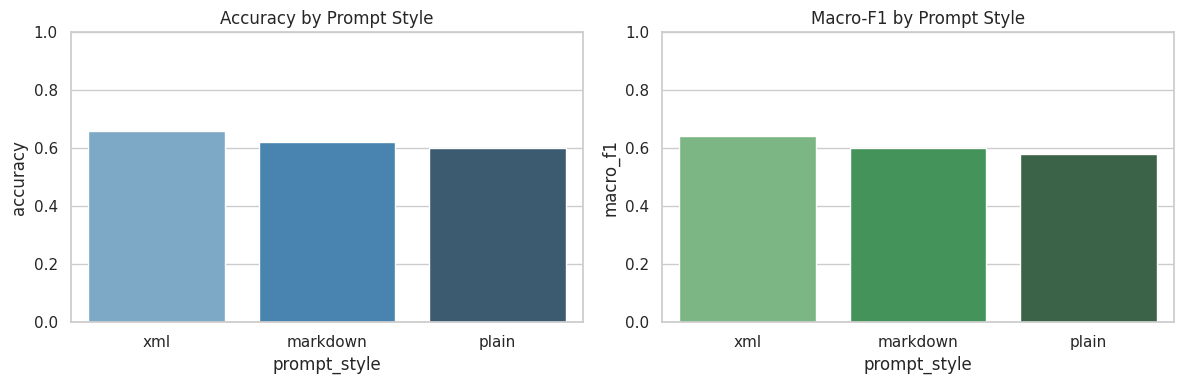

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=metrics_df, x="prompt_style", y="accuracy", ax=axes[0], palette="Blues_d")
axes[0].set_title("Accuracy by Prompt Style")
axes[0].set_ylim(0, 1)

sns.barplot(data=metrics_df, x="prompt_style", y="macro_f1", ax=axes[1], palette="Greens_d")
axes[1].set_title("Macro-F1 by Prompt Style")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

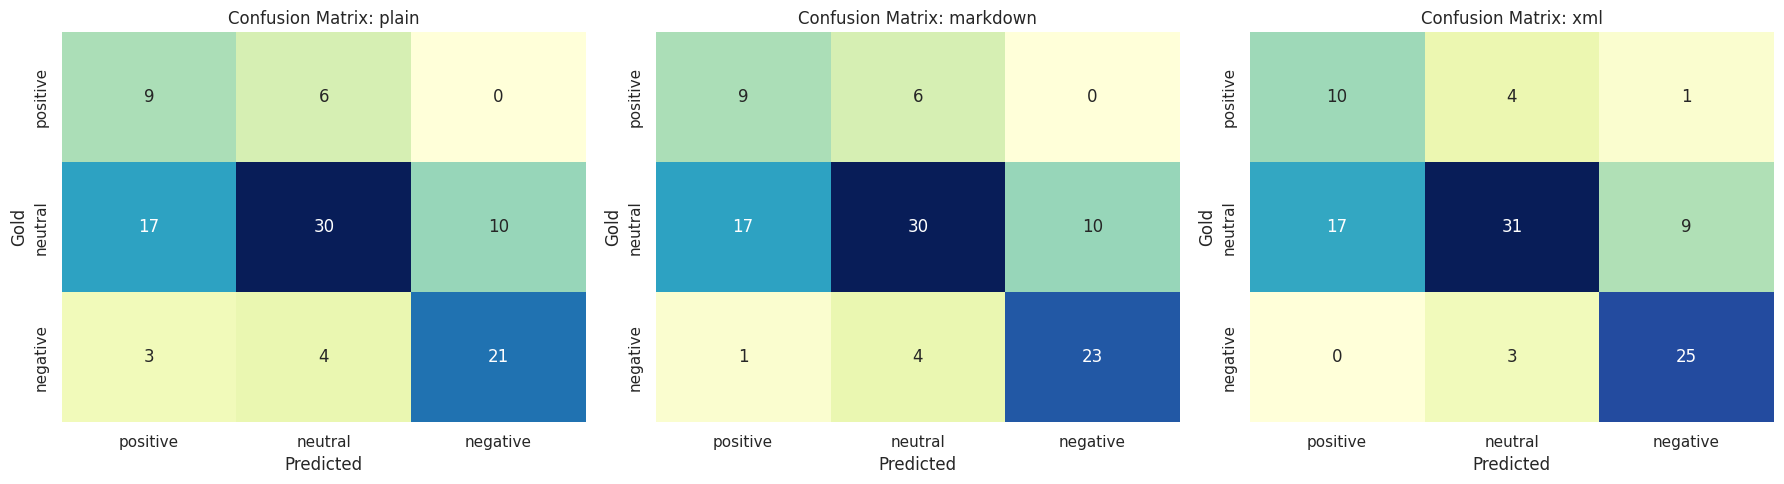

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, prompt_style in zip(axes, ["plain", "markdown", "xml"]):
    sns.heatmap(
        confusion_tables[prompt_style],
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix: {prompt_style}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")

plt.tight_layout()
plt.show()

In [ ]:
for prompt_style in ["plain", "markdown", "xml"]:
    print("=" * 80)
    print(f"Classification report: {prompt_style}")
    display(report_tables[prompt_style].round(3))

Classification report: plain


,precision,recall,f1-score,support
positive,0.310,0.600,0.409,15.0
neutral,0.750,0.526,0.619,57.0
negative,0.677,0.750,0.712,28.0
accuracy,0.600,0.600,0.600,0.6
macro avg,0.579,0.625,0.580,100.0
weighted avg,0.664,0.600,0.613,100.0


Classification report: markdown


,precision,recall,f1-score,support
positive,0.333,0.600,0.429,15.00
neutral,0.750,0.526,0.619,57.00
negative,0.697,0.821,0.754,28.00
accuracy,0.620,0.620,0.620,0.62
macro avg,0.593,0.649,0.600,100.00
weighted avg,0.673,0.620,0.628,100.00


Classification report: xml


,precision,recall,f1-score,support
positive,0.370,0.667,0.476,15.00
neutral,0.816,0.544,0.653,57.00
negative,0.714,0.893,0.794,28.00
accuracy,0.660,0.660,0.660,0.66
macro avg,0.633,0.701,0.641,100.00
weighted avg,0.721,0.660,0.666,100.00


**Takeaway:** อย่าดูแค่ accuracy อย่างเดียว
เพราะ confusion matrix และ classification report จะบอกชัดว่าแต่ละ prompt พลาด class ไหนบ่อย

## 13) Error Analysis แบบเร็ว

In [ ]:
disagreement_df = comparison_df[
    (comparison_df["pred_plain"] != comparison_df["pred_markdown"])
    | (comparison_df["pred_plain"] != comparison_df["pred_xml"])
    | (comparison_df["pred_markdown"] != comparison_df["pred_xml"])
].copy()

disagreement_df.head(20)

,id,text,gold_label,pred_plain,pred_markdown,pred_xml
4,5,ทานได้ค่ะ น้ำซุป MK ต้มมาจากหัวผักกาด ซีอิ้วขาว เกลือ แลน้ำตาลค่ะ,neutral,positive,neutral,positive
7,8,เจ้ว่าการ์นิเย่แอบแรงนิสหน่อย เคยใช้โยเกิร์ตไม๊ พรุ้งนี้ลองพอกหน้าดูทำให้หน้าสบายขึ้น นุ่มขึ้น หายไวไวน๊าาาา,negative,positive,positive,neutral
17,18,ตู้วหูวววว กะเพราเป็ดย่างงงง,neutral,neutral,positive,neutral
21,22,มึงนอกใจแสงโสมตั้งแต่เมื่อไหร่5555,neutral,negative,negative,neutral
24,25,ฟอร์ด แนะนำเทคนิคขับออฟโรดแบบง่ายๆ,neutral,positive,neutral,positive
29,30,อ๊ะ ไปก็ไป,positive,neutral,neutral,negative
33,34,ก็เพิ่งรู้ว่ามีผ้าอนามัยแบบสอด😂,neutral,neutral,positive,positive
40,41,โดนผีสิงห์ .. ลุกมะไหวเบยยย #singha,negative,positive,negative,negative
44,45,อยากดู เทียน่า2011สีขาวพอจะมีไหมครับ,neutral,positive,neutral,neutral
45,46,ห่ากูรอมึงรีวิวอยุ่กูถึงจะซื้อแดกเนียไม่กล้ากลัวไม่อร่อยคืนนี้ต้องจัด,negative,positive,neutral,negative


## 14) Exercises

ลองทำต่อเอง:
1. เปลี่ยน `OPENAI_MODEL` แล้วดูว่าอันดับของ prompt style ยังเหมือนเดิมไหม
2. เพิ่ม few-shot examples เข้าไปใน Plain prompt แล้วเปรียบเทียบอีกครั้ง
3. ขยาย eval set จาก 100 เป็น 300 แถว แล้วดูว่า metric ยังเสถียรหรือไม่

Pitfall ที่พบบ่อย:
- model ตอบ JSON ไม่ครบทุก id
- dataset label ไม่ถูก normalize ก่อนวัดผล
- batch ใหญ่เกินไปจน response ยาวและ parse ยาก

Extension:
- เพิ่ม cost / latency comparison ต่อ prompt style

In [ ]:
FEWSHOT_NOTE = "TODO: add a fourth prompt variant here and reuse the same evaluation pattern"
FEWSHOT_NOTE

'TODO: add a fourth prompt variant here and reuse the same evaluation pattern'

## 15) สรุป

จาก notebook นี้ เราได้ทำ workflow ครบตั้งแต่:
- โหลดชุดข้อมูลจริง
- ออกแบบ prompt หลายรูปแบบ
- รัน inference แบบ batch ทีละ 10 แถว
- ดู progress ผ่าน `tqdm` และ print ผลระหว่าง batch
- รวมผลลง DataFrame
- วัดผลด้วย metric และ visualization

แนวคิดสำคัญคือ prompt engineering ควรดูด้วย "ผลวัดได้" ไม่ใช่ดูแค่ความรู้สึกว่ารูปแบบไหนดูเป็นระเบียบกว่า